# Implementación de Transformers para Procesamiento de Lenguaje Natural (NLP)


### Objetivo
En esta evaluación, implementaremos un modelo basado en arquitecturas de Transformers para una tarea de procesamiento de lenguaje natural (NLP), utilizando el dataset **DailyDialog**. Este conjunto de datos de diálogos permite que el modelo practique en generación de texto y comprensión de contexto en interacciones cotidianas.

Usaremos TensorFlow para construir un modelo transformer básico con las siguientes características:
- **Encoder-Decoder**: para procesar la entrada y generar salida secuencial.
- **Atención Multi-cabezal**: para capturar dependencias a largo plazo en el diálogo.

Al final, evaluaremos el modelo utilizando métricas específicas de NLP, como BLEU o ROUGE.


## 1. Carga y Exploración del Dataset: DailyDialog

In [1]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/train.csv
!wget https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/test.csv
!wget https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/validation.csv

--2025-06-29 22:54:29--  https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6233555 (5.9M) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]   5.94M  --.-KB/s    in 0.02s   

2025-06-29 22:54:30 (354 MB/s) - ‘train.csv’ saved [6233555/6233555]

--2025-06-29 22:54:30--  https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 561656 (548K

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import ast
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import corpus_bleu
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import random
import pickle
import json

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
validation = pd.read_csv('validation.csv')

In [4]:
train

,dialog,act,emotion
0,"['Say , Jim , how about going for a few beers ...",[3 4 2 2 2 3 4 1 3 4],[0 0 0 0 0 0 4 4 4 4]
1,"['Can you do push-ups ? '\n "" Of course I can ...",[2 1 2 2 1 1],[0 0 6 0 0 0]
2,"['Can you study with the radio on ? '\n ' No ,...",[2 1 2 1 1],[0 0 0 0 0]
3,['Are you all right ? '\n ' I will be all righ...,[2 1 1 1],[0 0 0 0]
4,"['Hey John , nice skates . Are they new ? '\n ...",[2 1 2 1 1 2 1 3 4],[0 0 0 0 0 6 0 6 0]
...,...,...,...
11113,"['Hello , I bought a pen in your shop just bef...",[1 1 1 2 3 2 1 4 1],[0 4 0 0 0 0 0 0 4]
11114,['Do you have any seats available ? ' ' Yes . ...,[2 1 2 1 3 4],[0 0 0 0 0 4]
11115,"['Uncle Ben , how did the Forbidden City get t...",[2 1 2 1 1 1 1 1 2 1 2 1 2 1 3 4],[0 0 6 0 6 0 0 0 0 0 0 0 0 0 4 0]
11116,"['May I help you , sir ? ' ' I want a pair of ...",[2 3 4 3],[0 0 0 0]


### Procesamiento

In [5]:
def split_dialog_into_messages(dialog_list):
    """
    Convierte una lista con un string largo en una lista de mensajes individuales
    """
    if len(dialog_list) == 1:
        # Es un string largo, necesitamos dividirlo
        full_dialog = dialog_list[0]

        # Dividir por oraciones (usando . ? !) pero manteniendo la puntuación
        import re

        # Patrón para dividir en oraciones manteniendo la puntuación
        sentences = re.split(r'(?<=[.!?])\s+', full_dialog)

        # Filtrar oraciones vacías y muy cortas
        messages = [msg.strip() for msg in sentences if msg.strip() and len(msg.strip()) > 3]

        return messages
    else:
        # Ya es una lista de mensajes individuales
        return dialog_list

In [6]:
def process_dialogs(df):
    """Procesar diálogos: parsing + división en mensajes"""
    # Primero el parsing original
    df['dialog'] = df['dialog'].apply(ast.literal_eval)

    # Luego dividir en mensajes individuales
    df['dialog'] = df['dialog'].apply(split_dialog_into_messages)

    return df

In [7]:
print("Procesando diálogos...")
train = process_dialogs(train)
test = process_dialogs(test)
validation = process_dialogs(validation)

Procesando diálogos...


In [8]:
print("\n=== VERIFICACIÓN  ===")
print("Primeros 3 diálogos procesados:")
for i in range(min(3, len(train))):
    dialog = train['dialog'].iloc[i]
    print(f"\nDiálogo {i}:")
    print(f"  Longitud: {len(dialog)} mensajes")
    print(f"  Tipo: {type(dialog)}")
    print(f"  Mensajes:")
    for j, msg in enumerate(dialog[:5]):  # Mostrar máximo 5 mensajes
        print(f"    {j+1}: {msg}")
    if len(dialog) > 5:
        print(f"    ... y {len(dialog)-5} mensajes más")


=== VERIFICACIÓN  ===
Primeros 3 diálogos procesados:

Diálogo 0:
  Longitud: 17 mensajes
  Tipo: <class 'list'>
  Mensajes:
    1: Say , Jim , how about going for a few beers after dinner ?
    2: You know that is tempting but is really not good for our fitness .
    3: What do you mean ?
    4: It will help us to relax .
    5: Do you really think so ?
    ... y 12 mensajes más

Diálogo 1:
  Longitud: 10 mensajes
  Tipo: <class 'list'>
  Mensajes:
    1: Can you do push-ups ?
    2: Of course I can .
    3: It's a piece of cake !
    4: Believe it or not , I can do 30 push-ups a minute .
    5: Really ?
    ... y 5 mensajes más

Diálogo 2:
  Longitud: 5 mensajes
  Tipo: <class 'list'>
  Mensajes:
    1: Can you study with the radio on ?
    2: No , I listen to background music .
    3: What is the difference ?
    4: The radio has too many comerials .
    5: That's true , but then you have to buy a record player .


In [9]:
def create_input_target_pairs(df):
    """
    cambio los tokens especiales
    """
    input_texts = []
    target_texts = []

    for idx, row in df.iterrows():
        dialog = row['dialog']

        if isinstance(dialog, list) and len(dialog) >= 2:
            for i in range(len(dialog) - 1):
                input_text = dialog[i].strip()
                target_text = dialog[i + 1].strip()

                if input_text and target_text:
                    input_texts.append(input_text)
                    # CAMBIO AQUÍ: usar [START] y [END] en lugar de <START> y <END>
                    target_texts.append('[start] ' + target_text + ' [end]')

    return input_texts, target_texts

In [10]:
print(f"\n=== CREANDO PARES INPUT-TARGET ===")
train_inputs, train_targets = create_input_target_pairs(train)
val_inputs, val_targets = create_input_target_pairs(test)
test_inputs, test_targets = create_input_target_pairs(validation)

print(f"Pares creados exitosamente:")
print(f"- Train: {len(train_inputs)} pares")
print(f"- Val: {len(val_inputs)} pares")
print(f"- Test: {len(test_inputs)} pares")


=== CREANDO PARES INPUT-TARGET ===
Pares creados exitosamente:
- Train: 128954 pares
- Val: 11638 pares
- Test: 11954 pares


In [11]:
# Mostrar ejemplos de pares
if len(train_inputs) > 0:
    print(f"\n=== EJEMPLOS DE PARES CREADOS ===")
    for i in range(min(5, len(train_inputs))):
        print(f"\nPar {i+1}:")
        print(f"  Input:  {train_inputs[i]}")
        print(f"  Target: {train_targets[i]}")


=== EJEMPLOS DE PARES CREADOS ===

Par 1:
  Input:  Say , Jim , how about going for a few beers after dinner ?
  Target: [start] You know that is tempting but is really not good for our fitness . [end]

Par 2:
  Input:  You know that is tempting but is really not good for our fitness .
  Target: [start] What do you mean ? [end]

Par 3:
  Input:  What do you mean ?
  Target: [start] It will help us to relax . [end]

Par 4:
  Input:  It will help us to relax .
  Target: [start] Do you really think so ? [end]

Par 5:
  Input:  Do you really think so ?
  Target: [start] I don't . [end]


### Tokenización

In [12]:
# Preparar todos los textos para tokenización
all_texts = train_inputs + train_targets + val_inputs + val_targets + test_inputs + test_targets
print(f"Total de textos para tokenización: {len(all_texts)}")

Total de textos para tokenización: 305092


In [13]:
# Configurar y ajustar tokenizer
VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='[UNK]',
                     filters='!"#$%&()*+,-./:;=?@\\^_`{|}~\t\n',  # NO filtrar []
                     lower=True)  # Cambiar a True para consistencia
special_tokens = ['[START]', '[END]', '[UNK]']

# Crear una lista que empiece con los tokens especiales repetidos muchas veces
tokens_repeated = special_tokens * 1000  # Repetir 1000 veces cada token especial

# Ajustar el tokenizer con tokens especiales + todos los textos
tokenizer.fit_on_texts(tokens_repeated + all_texts)

# Verificar tokens especiales
start_token_idx = tokenizer.word_index.get('[start]', 1)
end_token_idx = tokenizer.word_index.get('[end]', 2)
oov_token_idx = tokenizer.word_index.get('[UNK]')        # mayúscula!


In [14]:
print(f"Tamaño del vocabulario: {len(tokenizer.word_index)}")
print(f"Índice de <START>: {start_token_idx}")
print(f"Índice de <END>: {end_token_idx}")
print(f"Índice de <OOV>: {oov_token_idx}")

# Verificación adicional - mostrar los primeros 10 tokens del vocabulario
print("\nPrimeros 10 tokens del vocabulario:")
sorted_vocab = sorted(tokenizer.word_index.items(), key=lambda x: x[1])
for word, idx in sorted_vocab[:10]:
    print(f"  {idx}: {word}")

Tamaño del vocabulario: 19261
Índice de <START>: 2
Índice de <END>: 3
Índice de <OOV>: 1

Primeros 10 tokens del vocabulario:
  1: [UNK]
  2: [start]
  3: [end]
  4: you
  5: i
  6: the
  7: to
  8: a
  9: it
  10: and


In [15]:
# Convertir a secuencias
train_input_seqs = tokenizer.texts_to_sequences(train_inputs)
train_target_seqs = tokenizer.texts_to_sequences(train_targets)
val_input_seqs = tokenizer.texts_to_sequences(val_inputs)
val_target_seqs = tokenizer.texts_to_sequences(val_targets)
test_input_seqs = tokenizer.texts_to_sequences(test_inputs)
test_target_seqs = tokenizer.texts_to_sequences(test_targets)

In [16]:
# Calcular longitudes máximas
def get_max_length(sequences):
    return max(len(seq) for seq in sequences)

max_input_len = max(
    get_max_length(train_input_seqs),
    get_max_length(val_input_seqs),
    get_max_length(test_input_seqs)
)

max_target_len = max(
    get_max_length(train_target_seqs),
    get_max_length(val_target_seqs),
    get_max_length(test_target_seqs)
)

max_len = max(max_input_len, max_target_len)
print(f"Longitud máxima unificada: {max_len}")

Longitud máxima unificada: 85


In [17]:
# Aplicar padding
def pad_all(sequences, maxlen):
    return pad_sequences(sequences, maxlen=maxlen, padding='post', truncating='post')

train_input_seqs = pad_all(train_input_seqs, max_len)
train_target_seqs = pad_all(train_target_seqs, max_len)
val_input_seqs = pad_all(val_input_seqs, max_len)
val_target_seqs = pad_all(val_target_seqs, max_len)
test_input_seqs = pad_all(test_input_seqs, max_len)
test_target_seqs = pad_all(test_target_seqs, max_len)

print("Padding aplicado")
print(f"Formas finales: {train_input_seqs.shape}, {train_target_seqs.shape}")

print(f"\n{'='*50}")
print("PROCESAMIENTO COMPLETADO")
print(f"{'='*50}")

Padding aplicado
Formas finales: (128954, 85), (128954, 85)

PROCESAMIENTO COMPLETADO


## 2. Implementación del Modelo Transformer

### Dataset

In [18]:
# Crear datasets de TensorFlow para seq2seq con teacher forcing
BATCH_SIZE = 32  # Reducido para mejor rendimiento con secuencias largas

def make_seq2seq_dataset(input_seqs, target_seqs, batch_size, shuffle=False):
    """
    Crear dataset de TensorFlow para entrenamiento seq2seq
    """
    # Target input: todo excepto el último token (para teacher forcing)
    target_input = target_seqs[:, :-1]
    # Target output: todo excepto el primer token (para calcular loss)
    target_output = target_seqs[:, 1:]

    # CORRECCIÓN: Crear el dataset correctamente
    dataset = tf.data.Dataset.from_tensor_slices((
        (input_seqs, target_input),  # Tupla de entradas
        target_output                # Salida
    ))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(10000, len(input_seqs)))

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [19]:
# Crear datasets con s2s
train_ds = make_seq2seq_dataset(train_input_seqs, train_target_seqs, BATCH_SIZE, shuffle=True)
val_ds = make_seq2seq_dataset(val_input_seqs, val_target_seqs, BATCH_SIZE)
test_ds = make_seq2seq_dataset(test_input_seqs, test_target_seqs, BATCH_SIZE)

In [20]:
# VERIFICAR FORMAS ANTES DE CREAR DATASET
print("Verificando formas de las secuencias:")
print(f"train_input_seqs shape: {train_input_seqs.shape}")
print(f"train_target_seqs shape: {train_target_seqs.shape}")
print(f"val_input_seqs shape: {val_input_seqs.shape}")
print(f"val_target_seqs shape: {val_target_seqs.shape}")

# Verificar que no haya secuencias vacías o de tamaño inconsistente
print(f"\nPrimeras 3 secuencias de entrada:")
for i in range(3):
    print(f"Input {i}: shape {train_input_seqs[i].shape}, sum: {np.sum(train_input_seqs[i])}")
    print(f"Target {i}: shape {train_target_seqs[i].shape}, sum: {np.sum(train_target_seqs[i])}")

Verificando formas de las secuencias:
train_input_seqs shape: (128954, 85)
train_target_seqs shape: (128954, 85)
val_input_seqs shape: (11638, 85)
val_target_seqs shape: (11638, 85)

Primeras 3 secuencias de entrada:
Input 0: shape (85,), sum: 5760
Target 0: shape (85,), sum: 7108
Input 1: shape (85,), sum: 7103
Target 1: shape (85,), sum: 246
Input 2: shape (85,), sum: 241
Target 2: shape (85,), sum: 1400


### Modelado

In [21]:
# Parámetros del modelo
VOCAB_SIZE = len(tokenizer.word_index) + 1 # padding
MAX_LEN = max_len
EMBEDDING_DIM = 128  # Reducido de 256
NUM_HEADS = 4        # Reducido de 8
FF_DIM = 256         # Reducido de 512
NUM_LAYERS = 2       # Reducido de 4
DROPOUT_RATE = 0.1

print(f"Parámetros del modelo:")
print(f"- Vocabulario: {VOCAB_SIZE}")
print(f"- Longitud máxima: {MAX_LEN}")
print(f"- Dimensión embedding: {EMBEDDING_DIM}")
print(f"- Número de cabezas de atención: {NUM_HEADS}")
print(f"- Dimensión feed-forward: {FF_DIM}")
print(f"- Número de capas: {NUM_LAYERS}")

Parámetros del modelo:
- Vocabulario: 19262
- Longitud máxima: 85
- Dimensión embedding: 128
- Número de cabezas de atención: 4
- Dimensión feed-forward: 256
- Número de capas: 2


In [22]:
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training=None, mask=None):
        attn_output = self.att(inputs, inputs, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [23]:
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        # agregar mask_zero=True
        self.token_emb = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            mask_zero=True  # Esto es crucial para manejar padding correctamente
        )
        self.pos_emb = tf.keras.layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [24]:
def create_transformer_model():
    # Encoder
    encoder_inputs = tf.keras.layers.Input(shape=(MAX_LEN,), name='encoder_input')
    encoder_embedding = TokenAndPositionEmbedding(MAX_LEN, VOCAB_SIZE, EMBEDDING_DIM)(encoder_inputs)

    encoder_output = encoder_embedding
    for _ in range(NUM_LAYERS):
        encoder_output = TransformerBlock(EMBEDDING_DIM, NUM_HEADS, FF_DIM, DROPOUT_RATE)(encoder_output)

    # Decoder
    decoder_inputs = tf.keras.layers.Input(shape=(MAX_LEN-1,), name='decoder_input')
    decoder_embedding = TokenAndPositionEmbedding(MAX_LEN-1, VOCAB_SIZE, EMBEDDING_DIM)(decoder_inputs)

    decoder_output = decoder_embedding
    for _ in range(NUM_LAYERS):
        # Atención propia del decoder con máscara causal
        causal_mask = tf.linalg.band_part(tf.ones((MAX_LEN-1, MAX_LEN-1)), -1, 0)
        decoder_output = TransformerBlock(EMBEDDING_DIM, NUM_HEADS, FF_DIM, DROPOUT_RATE)(
            decoder_output, mask=causal_mask
        )

        # Atención cruzada (decoder atiende claramente al encoder)
        cross_attn_output = tf.keras.layers.MultiHeadAttention(
            num_heads=NUM_HEADS, key_dim=EMBEDDING_DIM
        )(
            query=decoder_output,
            value=encoder_output,
            key=encoder_output
        )

        # Residual connection y layer normalization claramente definidos
        decoder_output = tf.keras.layers.LayerNormalization(epsilon=1e-6)(decoder_output + cross_attn_output)

    # Capa de salida claramente definida
    decoder_output = tf.keras.layers.Dense(VOCAB_SIZE, activation='softmax')(decoder_output)

    # Modelo claramente definido
    model = tf.keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs=decoder_output,
        name='transformer_chatbot'
    )

    return model


In [25]:
# crear el modelo
model = create_transformer_model()

# Compilar modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen del modelo
model.summary()

Model: "transformer_chatbot"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 85)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 84)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 85, 128)   │  2,476,416 │ encoder_input[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 84, 128)   │  2,476,288 │ decoder_input[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ (None, 85, 128)   │    330,240 │ token_and_positi… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, 84, 128)   │    330,240 │ token_and_positi… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 85, 128)   │    330,240 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 84, 128)   │    263,808 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ transformer_bloc… │
│                     │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 84, 128)   │          0 │ transformer_bloc… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 84, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (None, 84, 128)   │    330,240 │ layer_normalizat… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 84, 128)   │    263,808 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ transformer_bloc… │
│                     │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 84, 128)   │          0 │ transformer_bloc… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 84, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 84, 19262) │  2,484,798 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,286,590 (35.43 MB)

 Trainable params: 9,286,590 (35.43 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento del Modelo

In [26]:
# Entrenar el modelo
print("\n=== ENTRENANDO MODELO ===")
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds
)


=== ENTRENANDO MODELO ===
Epoch 1/20
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 261s 45ms/step - accuracy: 0.9077 - loss: 2.0354 - val_accuracy: 0.9253 - val_loss: 0.4759
Epoch 2/20
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - accuracy: 0.9256 - loss: 0.4650 - val_accuracy: 0.9273 - val_loss: 0.4445
Epoch 3/20
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - accuracy: 0.9273 - loss: 0.4344 - val_accuracy: 0.9283 - val_loss: 0.4290
Epoch 4/20
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - accuracy: 0.9288 - loss: 0.4123 - val_accuracy: 0.9289 - val_loss: 0.4184
Epoch 5/20
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - accuracy: 0.9302 - loss: 0.3944 - val_accuracy: 0.9294 - val_loss: 0.4120
Epoch 6/20
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - accuracy: 0.9314 - loss: 0.3795 - val_accuracy: 0.9299 - val_loss: 0.4066
Epoch 7/20
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - accuracy: 0.9328 - loss: 0.3652 - val_accuracy: 0.9302 - val_loss: 0.4030
Epoch 8/20
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 

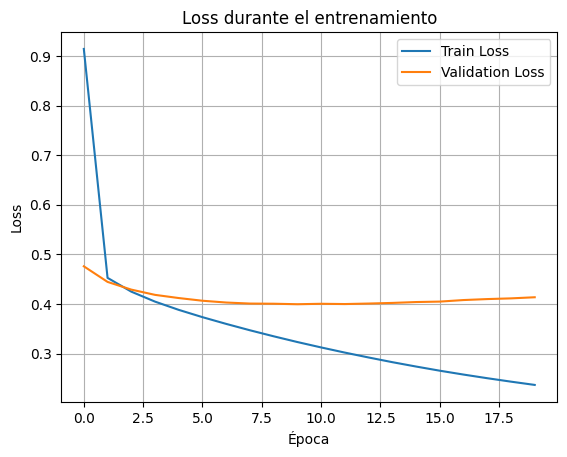

In [27]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.show()

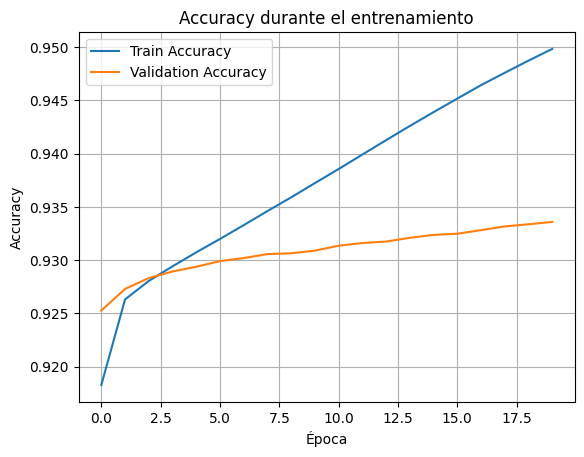

In [28]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.show()


## 4. Evaluación del Modelo

In [29]:
def decode_sequence(input_text, model, tokenizer, max_len=30):
    input_seq = tokenizer.texts_to_sequences([input_text])
    input_seq = pad_sequences(input_seq, maxlen=MAX_LEN, padding='post')

    start_token_idx = tokenizer.word_index['[start]']
    end_token_idx = tokenizer.word_index['[end]']
    decoder_input = [start_token_idx]

    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}

    for _ in range(max_len):
        decoder_seq = pad_sequences([decoder_input], maxlen=MAX_LEN-1, padding='post')

        preds = model.predict([input_seq, decoder_seq], verbose=0)
        pred_token = np.argmax(preds[0, len(decoder_input)-1, :])

        if pred_token == end_token_idx or pred_token == 0:
            break

        decoder_input.append(pred_token)

    return ' '.join(reverse_word_index.get(idx, '[UNK]') for idx in decoder_input[1:])

In [30]:
# Función adicional para probar múltiples entradas
def test_chatbot(model, tokenizer, test_inputs=None):
    """
    Función para probar el chatbot con múltiples entradas
    """
    if test_inputs is None:
        test_inputs = [
            "Hello, how are you?",
            "What's your name?",
            "How was your day?",
            "Tell me about yourself",
            "What do you like to do?"
        ]

    print("=== PROBANDO EL CHATBOT ===\n")

    for i, input_text in enumerate(test_inputs, 1):
        print(f"Prueba {i}:")
        print(f"Input: {input_text}")

        try:
            response = decode_sequence(input_text, model, tokenizer, max_len=30)
            print(f"Output: {response}")
        except Exception as e:
            print(f"Error: {e}")

        print("-" * 50)

In [31]:
def verify_tokenizer(tokenizer):
    print("=== VERIFICACIÓN DEL TOKENIZER ===")
    start_idx = tokenizer.word_index.get('[start]')
    end_idx = tokenizer.word_index.get('[end]')
    oov_idx = tokenizer.word_index.get('[UNK]')

    print(f"Tamaño del vocabulario: {len(tokenizer.word_index)}")
    print(f"Índice [START]: {start_idx}")
    print(f"Índice [END]: {end_idx}")
    print(f"Índice [UNK]: {oov_idx}")

    if start_idx and end_idx and oov_idx:
        print("Tokens especiales encontrados correctamente")
    else:
        print("Tokens especiales NO encontrados correctamente")

In [32]:
def debug_prediction(input_text, model, tokenizer):
    print(f"=== DEBUG: '{input_text}' ===")

    input_seq = tokenizer.texts_to_sequences([input_text])
    input_seq_padded = pad_sequences(input_seq, maxlen=MAX_LEN, padding='post')

    start_token_idx = tokenizer.word_index.get('[start]', 1)
    end_token_idx = tokenizer.word_index.get('[end]', 2)
    print(f"Token START: {start_token_idx}, Token END: {end_token_idx}")

    decoder_input = [start_token_idx]
    decoder_seq = pad_sequences([decoder_input], maxlen=MAX_LEN-1, padding='post')

    prediction = model.predict([input_seq_padded, decoder_seq], verbose=0)
    print(f"Forma de predicción: {prediction.shape}")
    print(f"Probabilidades más altas:")

    top_indices = np.argsort(prediction[0, 0, :])[-5:][::-1]
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}

    for idx in top_indices:
        prob = prediction[0, 0, idx]
        word = reverse_word_index.get(idx, f'<IDX_{idx}>')
        print(f"  {word}: {prob:.4f}")


In [33]:
response = decode_sequence("how are you?", model, tokenizer, max_len=50)
print("Respuesta del modelo:", response)

Respuesta del modelo: i'm fine


In [34]:
# verificar que el tokenizer esté configurado correctamente
verify_tokenizer(tokenizer)

# debug detallado de una predicción
debug_prediction("how are you?", model, tokenizer)

# chatbot con múltiples entradas
test_chatbot(model, tokenizer)

#  entrada específica
response = decode_sequence("how are you?", model, tokenizer, max_len=30)
print("Respuesta del modelo:", response)

=== VERIFICACIÓN DEL TOKENIZER ===
Tamaño del vocabulario: 19261
Índice [START]: 2
Índice [END]: 3
Índice [UNK]: 1
Tokens especiales encontrados correctamente
=== DEBUG: 'how are you?' ===
Token START: 2, Token END: 3
Forma de predicción: (1, 84, 19262)
Probabilidades más altas:
  i'm: 0.1907
  i: 0.1412
  fine: 0.1074
  good: 0.0682
  just: 0.0524
=== PROBANDO EL CHATBOT ===

Prueba 1:
Input: Hello, how are you?
Output: i'm looking for a job
--------------------------------------------------
Prueba 2:
Input: What's your name?
Output: my name is david white
--------------------------------------------------
Prueba 3:
Input: How was your day?
Output: i was just wondering about the day
--------------------------------------------------
Prueba 4:
Input: Tell me about yourself
Output: i ’ m going to the company
--------------------------------------------------
Prueba 5:
Input: What do you like to do?
Output: it's a fruit with a big nut in it
-----------------------------------------------

In [35]:
generated_sentences = []
reference_sentences = []

for input_text, target_text in list(zip(test_inputs, test_targets))[:500]:
    pred = decode_sequence(input_text, model, tokenizer)
    generated_sentences.append(pred.split())
    reference_sentences.append([target_text.replace('[start]', '').replace('[end]', '').strip().split()])

In [36]:
bleu_score = corpus_bleu(reference_sentences, generated_sentences)
print("BLEU Score (200 muestras):", bleu_score * 100)

BLEU Score (200 muestras): 0.9984613658416217


## 5. Ajuste de Hiperparámetros

In [37]:

# Probar diferentes configuraciones de hiperparámetros
# Ejemplo: modificar num_heads, ff_dim, número de capas

# Documentar los resultados y evaluar cada configuración
# for num_heads in [2, 4, 8]:
#     for ff_dim in [32, 64, 128]:
#         # Redefinir y entrenar modelo con nuevos hiperparámetros
#         # Registrar métricas y comparar rendimiento


In [38]:
# Seleccionar 10 índices aleatorios no consecutivos del test
random.seed(28)
indices = random.sample(range(len(test_inputs)), 10)

print("Respuestas del modelo a preguntas variadas:\n")

for i, idx in enumerate(indices, 1):
    input_text = test_inputs[idx]
    prediction = decode_sequence(input_text, model, tokenizer)
    reference = test_targets[idx].replace('[start]', '').replace('[end]', '').strip()

    display(Markdown(f"""
### Pregunta {i}
- **Input:** {input_text}
- **Esperado:** {reference}
- **Generado:** {prediction}
---
"""))

Respuestas del modelo a preguntas variadas:




### Pregunta 1
- **Input:** I see there are some workmen on the site .
- **Esperado:** When is the building work due to start ?
- **Generado:** i don ’ t want to go to the hardware
---



### Pregunta 2
- **Input:** What did you do ?
- **Esperado:** I stood behind the register and took pizza orders .
- **Generado:** i was a little worried about my chest
---



### Pregunta 3
- **Input:** Yes , here you go .
- **Esperado:** I don't need a visa to go to Spain , do I ?
- **Generado:** thank you
---



### Pregunta 4
- **Input:** 349-95- 8821 .
- **Esperado:** Do you have medical insurance ?
- **Generado:** do you have medical insurance
---


...


### Pregunta 6
- **Input:** Now you're my boss , Mr .
- **Esperado:** Henry .
- **Generado:** smith
---



### Pregunta 7
- **Input:** A friend suggested that I stop nibbling between meals .
- **Esperado:** Like snacking ?
- **Generado:** you should have to know your voice is specially order
---



### Pregunta 8
- **Input:** Not at all .
- **Esperado:** These private sales are great places to bargain .
- **Generado:** i ’ ll be glad to
---



### Pregunta 9
- **Input:** Would you help me ?
- **Esperado:** Would you turn off the tap ?
- **Generado:** yes i'd like to book a room for a week
---



### Pregunta 10
- **Input:** I'll just stay here until you get back .
- **Esperado:** So the total is $ 36.00 for our dinner .
- **Generado:** thanks
---


## 6. Presentación de Resultados y Conclusiones


En esta sección, resumiremos los resultados obtenidos, mostrando cómo los ajustes de los hiperparámetros impactaron en el rendimiento del modelo.
- **Resultados Finales**: Comparación de BLEU, ROUGE, y otras métricas para cada configuración.
- **Conclusiones**: Reflexión sobre el proceso, dificultades encontradas y aprendizajes obtenidos.

¡Gracias por revisar nuestro proyecto! Esperamos que esta implementación demuestre nuestro dominio en el uso de transformers para NLP.


In [39]:
# Opción 1: Guardar modelo completo (RECOMENDADO)
model.save('transformer_chatbot_completo.keras')

# Guardar también el tokenizer (MUY IMPORTANTE)
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Guardar configuración importante
config = {
    'VOCAB_SIZE': VOCAB_SIZE,
    'MAX_LEN': MAX_LEN,
    'EMBEDDING_DIM': EMBEDDING_DIM,
    'NUM_HEADS': NUM_HEADS,
    'FF_DIM': FF_DIM,
    'NUM_LAYERS': NUM_LAYERS,
    'DROPOUT_RATE': DROPOUT_RATE
}

with open('model_config.pkl', 'wb') as f:
    pickle.dump(config, f)

print("Modelo, tokenizer y configuración guardados exitosamente!")

Modelo, tokenizer y configuración guardados exitosamente!
